# EDA: Multi-Year WNBA Player Salary Dataset (2021–2025)

Exploratory data analysis of the combined 2021–2025 WNBA player salary and production dataset.

**Sections:**
1. Data loading & integration (from `assessing_learnability_multiyear.ipynb`)
2. Per-year row counts and data quality check
3. Distributions and descriptive stats
4. Missingness analysis
5. Relationships between variables
6. Year-over-year trends
7. Outlier detection


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
from sklearn.ensemble import IsolationForest

sns.set_theme(style="whitegrid")


## 1. Data Loading & Integration

Identical merge logic to `assessing_learnability_multiyear.ipynb`.

In [2]:
repo = Path.cwd().parent
data_dir = repo / "data" / "raw"
years = list(range(2021, 2026))

raw = {}
for year in years:
    raw[year] = {
        "advanced":      pd.read_csv(data_dir / f"{year}_advanced.csv"),
        "per_game":      pd.read_csv(data_dir / f"{year}_per_game.csv"),
        "totals":        pd.read_csv(data_dir / f"{year}_totals.csv"),
        "salary":        pd.read_csv(data_dir / f"salary_{year}.csv"),
        "team_advanced": pd.read_csv(data_dir / f"{year}_advanced-team.csv"),
        "standings":     pd.read_csv(data_dir / f"{year}_wnba_standings.csv"),
    }

print("Raw file shapes:")
for year, files in raw.items():
    shapes = {name: df.shape for name, df in files.items()}
    print(f"  {year}: {shapes}")


Raw file shapes:
  2021: {'advanced': (155, 24), 'per_game': (155, 27), 'totals': (155, 26), 'salary': (191, 27), 'team_advanced': (12, 27), 'standings': (12, 5)}
  2022: {'advanced': (166, 24), 'per_game': (166, 27), 'totals': (166, 26), 'salary': (202, 27), 'team_advanced': (12, 27), 'standings': (12, 5)}
  2023: {'advanced': (156, 24), 'per_game': (156, 27), 'totals': (156, 26), 'salary': (184, 27), 'team_advanced': (12, 27), 'standings': (12, 5)}
  2024: {'advanced': (157, 24), 'per_game': (157, 27), 'totals': (157, 26), 'salary': (180, 27), 'team_advanced': (12, 27), 'standings': (12, 5)}
  2025: {'advanced': (182, 24), 'per_game': (182, 27), 'totals': (182, 26), 'salary': (227, 27), 'team_advanced': (13, 27), 'standings': (13, 5)}


In [3]:
def clean_col(name):
    text = str(name).strip().lower()
    text = re.sub(r"20\d{2}\s+salary", "salary", text)
    text = re.sub(r"20\d{2}\s+signing", "signing", text)
    text = text.replace("%", "pct")
    text = re.sub(r"[^0-9a-z]+", "_", text)
    return text.strip("_")

def clean_df(df):
    df = df.copy()
    df.columns = [clean_col(col) for col in df.columns]
    for col in df.select_dtypes(include=["object", "string"]).columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"": np.nan, "—": np.nan, "nan": np.nan})
    return df

cleaned = {}
for year, files in raw.items():
    cleaned[year] = {name: clean_df(df) for name, df in files.items()}
    cleaned[year]["salary"]["salary"] = pd.to_numeric(
        cleaned[year]["salary"]["salary"], errors="coerce")


In [4]:
teammap = {
    "Atlanta Dream": "ATL",       "Chicago Sky": "CHI",
    "Connecticut Sun": "CON",     "Dallas Wings": "DAL",
    "Golden State Valkyries": "GSV", "Indiana Fever": "IND",
    "Las Vegas Aces": "LVA",      "Los Angeles Sparks": "LAS",
    "Minnesota Lynx": "MIN",      "New York Liberty": "NYL",
    "Phoenix Mercury": "PHO",     "Seattle Storm": "SEA",
    "Washington Mystics": "WAS",
}

name_fix = {
    "AD Durr": "Asia (AD) Durr",
    "Anastasiia Kosu": "Anastasiia Olairi Kosu",
    "Azurá Stevens": "Azura Stevens",
    "Brittany Boyd": "Brittany Boyd-Jones",
    "Dorka JuhÃ¡sz": "Dorka Juhasz",   "Dorka Juhász": "Dorka Juhasz",
    "Ivana DojkiÄ": "Ivana Dojkic",    "Ivana Dojkić": "Ivana Dojkic",
    "Janelle SalaÃ¼n": "Janelle Salaun","Janelle Salaün": "Janelle Salaun",
    "LeÃ¯la Lacan": "Leila Lacan",      "Leïla Lacan": "Leila Lacan",
    "Lou Lopez SÃ©nÃ©chal": "Lou Lopez Senechal",
    "Lou Lopez Sénéchal": "Lou Lopez Senechal",
    "Luisa GeiselsÃ¶der": "Luisa Geiselsoder",
    "Luisa Geiselsöder": "Luisa Geiselsoder",
    "Mamignan TourÃ©": "Mamignan Toure","Mamignan Touré": "Mamignan Toure",
    "MariÃ¨me Badiane": "Marieme Badiane","Marième Badiane": "Marieme Badiane",
    "Nika MÃ¼hl": "Nika Muhl",          "Nika Mühl": "Nika Muhl",
    "Olivia Ãpoupa": "Olivia Epoupa",   "Olivia Époupa": "Olivia Epoupa",
    "Sika KonÃ©": "Sika Kone",          "Sika Koné": "Sika Kone",
    "Te-Hina PaoPao": "Te-Hina Paopao",
    "Temi Fágbénlé": "Temi Fagbenle",
}

season_dfs = []
for year in years:
    adv     = cleaned[year]["advanced"]
    per     = cleaned[year]["per_game"]
    tot     = cleaned[year]["totals"]
    sal     = cleaned[year]["salary"].copy()
    teamadv = cleaned[year]["team_advanced"].copy()
    stand   = cleaned[year]["standings"].copy()

    teamadv["team_name"] = teamadv["team"].apply(
        lambda v: str(v).replace("*", "").strip() if pd.notna(v) else np.nan)
    teamadv["team"] = teamadv["team_name"].map(teammap)
    stand["team_name"] = stand["team_name"].apply(
        lambda v: str(v).replace("*", "").strip() if pd.notna(v) else np.nan)
    stand["team"] = stand["team_name"].map(teammap)

    teamdf   = teamadv.merge(stand, on=["team", "team_name"], how="left",
                             suffixes=("_adv", "_stand"))
    playerdf = per.merge(adv, on=["player", "team", "pos", "g", "mp"],
                         how="outer", suffixes=("_per", "_adv"))
    playerdf = playerdf.merge(tot, on=["player", "team", "pos", "g", "mp", "gs"],
                              how="outer", suffixes=("", "_tot"))

    sal["player"]      = sal["player"].replace(name_fix)
    playerdf["player"] = playerdf["player"].replace(name_fix)

    seasondf = sal.merge(playerdf, on="player", how="inner", suffixes=("_sal", ""))
    seasondf = seasondf.merge(teamdf, on="team", how="left", suffixes=("", "_team"))
    seasondf["season"] = year
    season_dfs.append(seasondf)

final_df = pd.concat(season_dfs, ignore_index=True)
final_df = final_df.copy()   # defragment

print(f"Combined dataset shape: {final_df.shape}")
final_df.head(3)


Combined dataset shape: (963, 124)


,player,salary,signing,g_sal,gs_sal,min,pts_sal,fgm,fga_sal,fgpct,...,opp_tov_pct,drb_pct,opp_ft_rate,arena_name,team_name,wins_stand,losses_stand,win_loss_pct,gb,season
0,Tina Charles,175000,UFA,27,27,33.3,23.4,8.8,19.6,44.9%,...,15.3,76.4,0.208,St. Elizabeths East Arena,Washington Mystics,12.0,20.0,0.375,14.0,2021
1,Brittney Griner,221450,NaN,30,30,32.8,20.5,8.3,14.4,57.5%,...,11.3,75.1,0.167,Phoenix Suns Arena,Phoenix Mercury,19.0,13.0,0.594,7.0,2021
2,Breanna Stewart,190550,NaN,28,28,33.3,20.3,6.9,15.8,43.9%,...,14.4,78.6,0.180,Angels of the Winds Arena,Seattle Storm,21.0,11.0,0.656,5.0,2021


## 2. Per-Year Data Quality Check

Before any analysis, confirm that each season has a reasonable number of players
and that salary coverage is complete.


In [5]:
# Row counts per season
per_year = (
    final_df.groupby("season")
    .agg(
        total_rows       = ("player", "count"),
        unique_players   = ("player", "nunique"),
        salary_coverage  = ("salary", lambda s: s.notna().sum()),
        tot_rows         = ("team",   lambda s: (s == "TOT").sum()),
        missing_team_ctx = ("team_name", lambda s: s.isna().sum()),
    )
    .reset_index()
)
per_year["salary_pct"] = (per_year["salary_coverage"] / per_year["total_rows"] * 100).round(1)
print("Per-season summary:")
display(per_year)


Per-season summary:


,season,total_rows,unique_players,salary_coverage,tot_rows,missing_team_ctx,salary_pct
0,2021,187,155,187,34,34,100.0
1,2022,200,166,200,37,37,100.0
2,2023,175,154,175,22,22,100.0
3,2024,177,155,177,25,25,100.0
4,2025,224,182,224,54,54,100.0


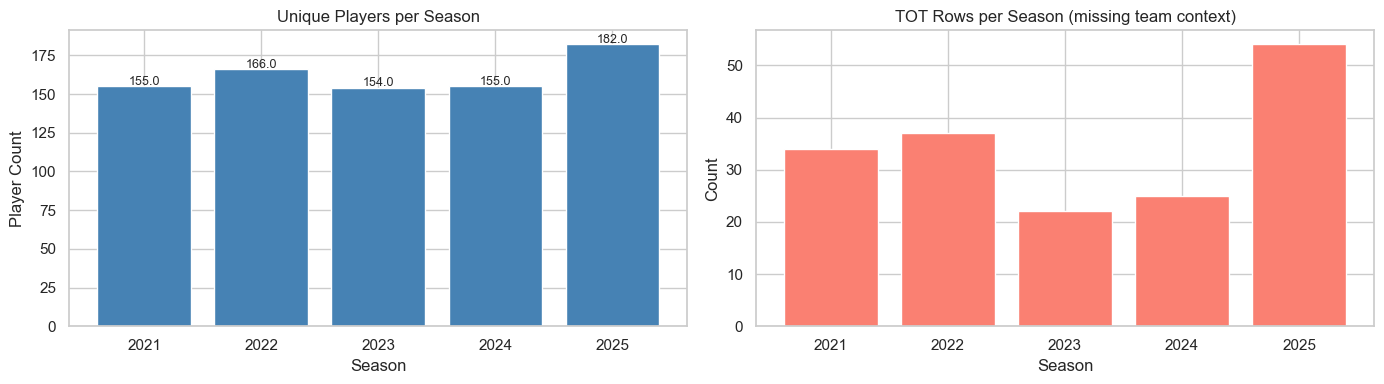

In [6]:
# Player count per season bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(per_year["season"].astype(str), per_year["unique_players"], color="steelblue")
axes[0].set_title("Unique Players per Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Player Count")
for i, row in per_year.iterrows():
    axes[0].text(i, row["unique_players"] + 1, str(row["unique_players"]), ha="center", fontsize=9)

axes[1].bar(per_year["season"].astype(str), per_year["tot_rows"], color="salmon")
axes[1].set_title("TOT Rows per Season (missing team context)")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## 3. Distributions and Descriptive Stats

Understand the spread of our target variable (`salary`) and key production features
across the full 2021–2025 dataset.


In [7]:
# Descriptive statistics 
cols_to_describe = [c for c in ["salary", "ws", "age", "pts_per_g", "mp_per_g"]
                    if c in final_df.columns]
print("Descriptive Statistics (2021-2025 combined):")
display(final_df[cols_to_describe].describe().round(2))


Descriptive Statistics (2021-2025 combined):


,salary,ws,age,pts_per_g,mp_per_g
count,963.00,963.00,791.00,963.00,963.00
mean,86580.83,1.22,27.71,6.99,17.96
std,68167.91,1.78,1.37,5.35,9.22
min,0.00,-1.60,24.80,0.00,0.00
25%,25644.00,0.00,26.80,2.60,10.30
50%,71300.00,0.60,27.80,5.70,17.30
75%,135925.00,2.00,28.80,10.10,26.15
max,269244.00,10.90,30.40,26.90,38.60


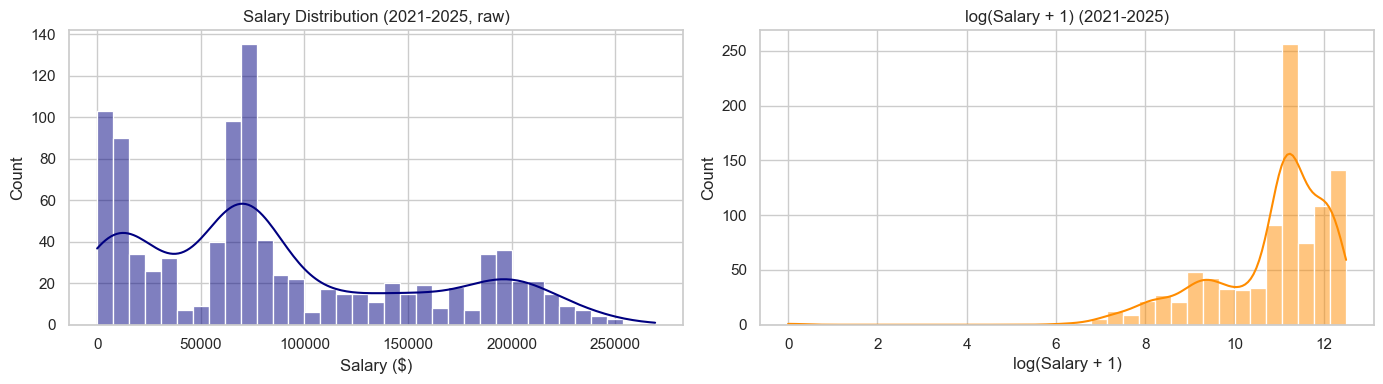

In [8]:


# Salary distribution: raw and log-transformed 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(final_df["salary"].dropna(), kde=True, bins=35,
             ax=axes[0], color="navy")
axes[0].set_title("Salary Distribution (2021-2025, raw)")
axes[0].set_xlabel("Salary ($)")
axes[0].set_ylabel("Count")

sns.histplot(np.log1p(final_df["salary"].dropna()), kde=True, bins=35,
             ax=axes[1], color="darkorange")
axes[1].set_title("log(Salary + 1) (2021-2025)")
axes[1].set_xlabel("log(Salary + 1)")

plt.tight_layout()
plt.show()


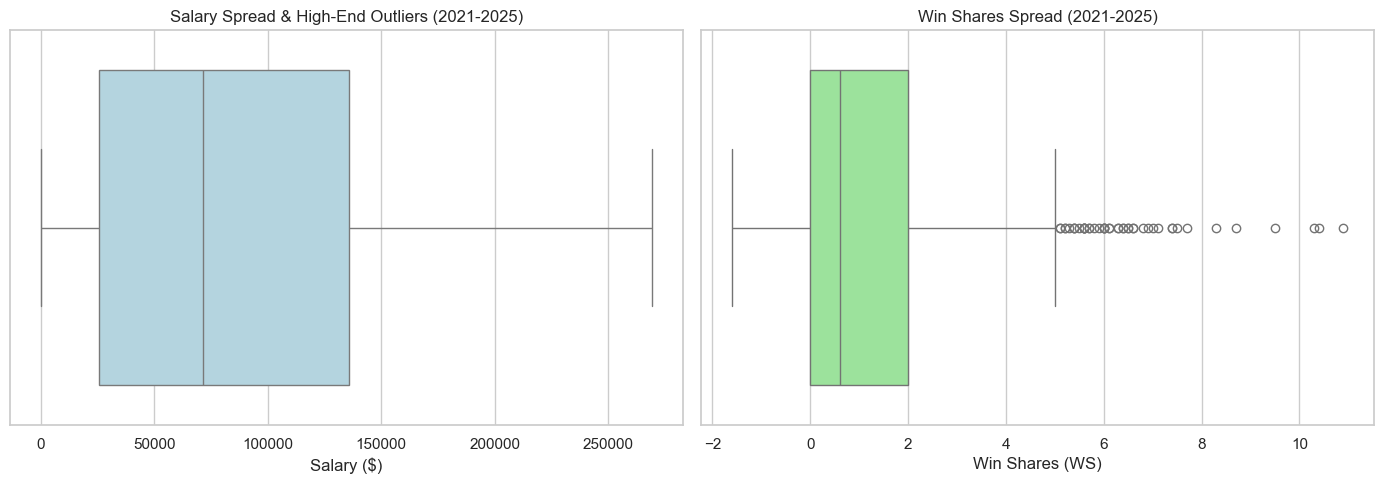

In [9]:
# Salary and Win Shares boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=final_df, x="salary", ax=axes[0], color="lightblue")
axes[0].set_title("Salary Spread & High-End Outliers (2021-2025)")
axes[0].set_xlabel("Salary ($)")

sns.boxplot(data=final_df, x="ws", ax=axes[1], color="lightgreen")
axes[1].set_title("Win Shares Spread (2021-2025)")
axes[1].set_xlabel("Win Shares (WS)")

plt.tight_layout()
plt.show()


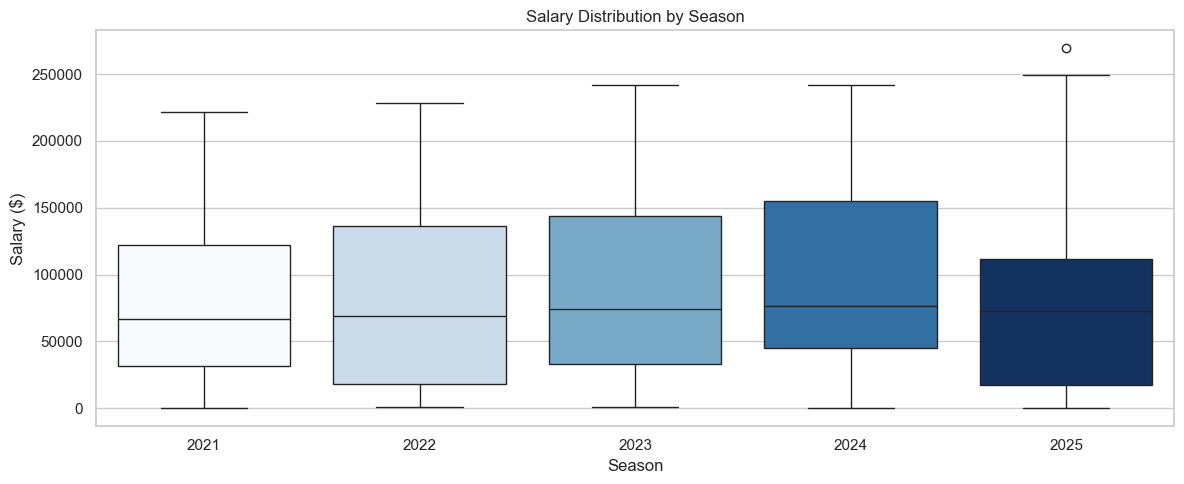

In [11]:
# Salary by season: boxplot
fig, ax = plt.subplots(figsize=(12, 5))

sns.boxplot(data=final_df, x="season", y="salary", ax=ax, hue="season", palette="Blues", legend=False)

ax.set_title("Salary Distribution by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Salary ($)")
plt.tight_layout()
plt.show()

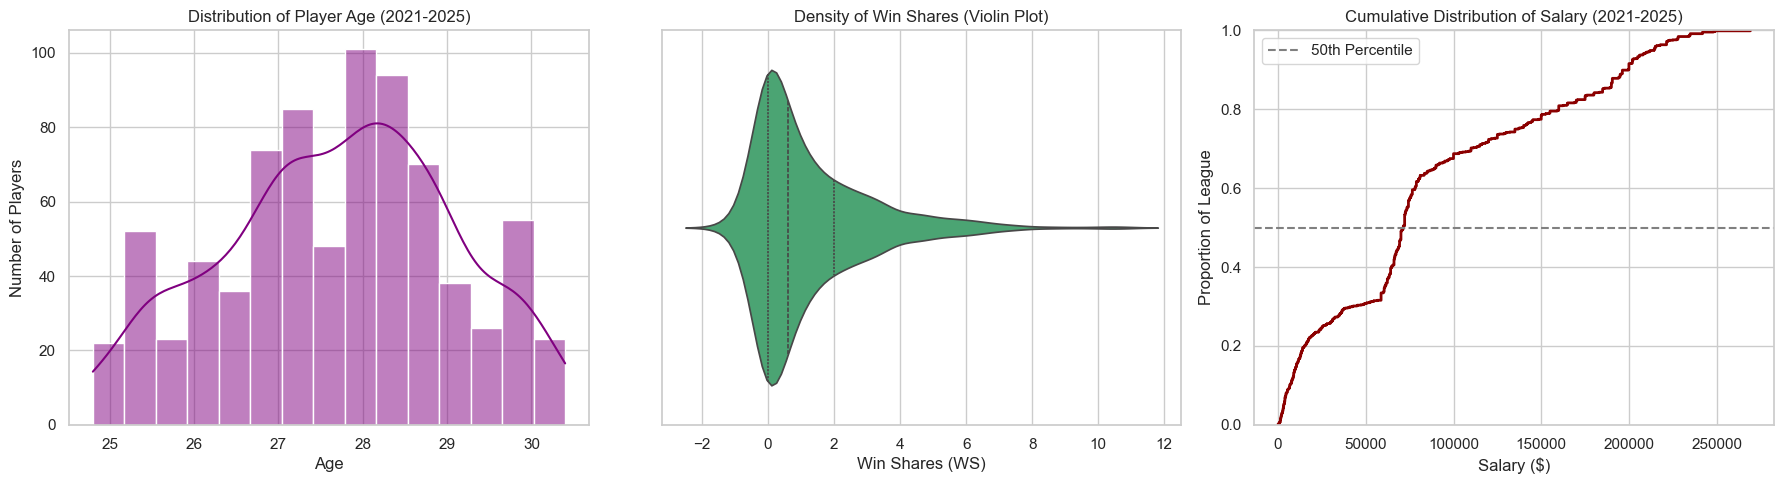

In [12]:
#Violin plot, ECDF, and age histogram
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age histogram
sns.histplot(data=final_df, x="age", kde=True, bins=15,
             ax=axes[0], color="purple")
axes[0].set_title("Distribution of Player Age (2021-2025)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of Players")

# Violin plot for win shares — shows distribution shape AND quartiles
sns.violinplot(data=final_df, x="ws", ax=axes[1],
               color="mediumseagreen", inner="quartile")
axes[1].set_title("Density of Win Shares (Violin Plot)")
axes[1].set_xlabel("Win Shares (WS)")

# ECDF for salary — shows what % of players earn below each salary level
sns.ecdfplot(data=final_df, x="salary", ax=axes[2],
             color="darkred", linewidth=2)
axes[2].set_title("Cumulative Distribution of Salary (2021-2025)")
axes[2].set_xlabel("Salary ($)")
axes[2].set_ylabel("Proportion of League")
axes[2].axhline(0.5, color="gray", linestyle="--", label="50th Percentile")
axes[2].legend()

plt.tight_layout()
plt.show()


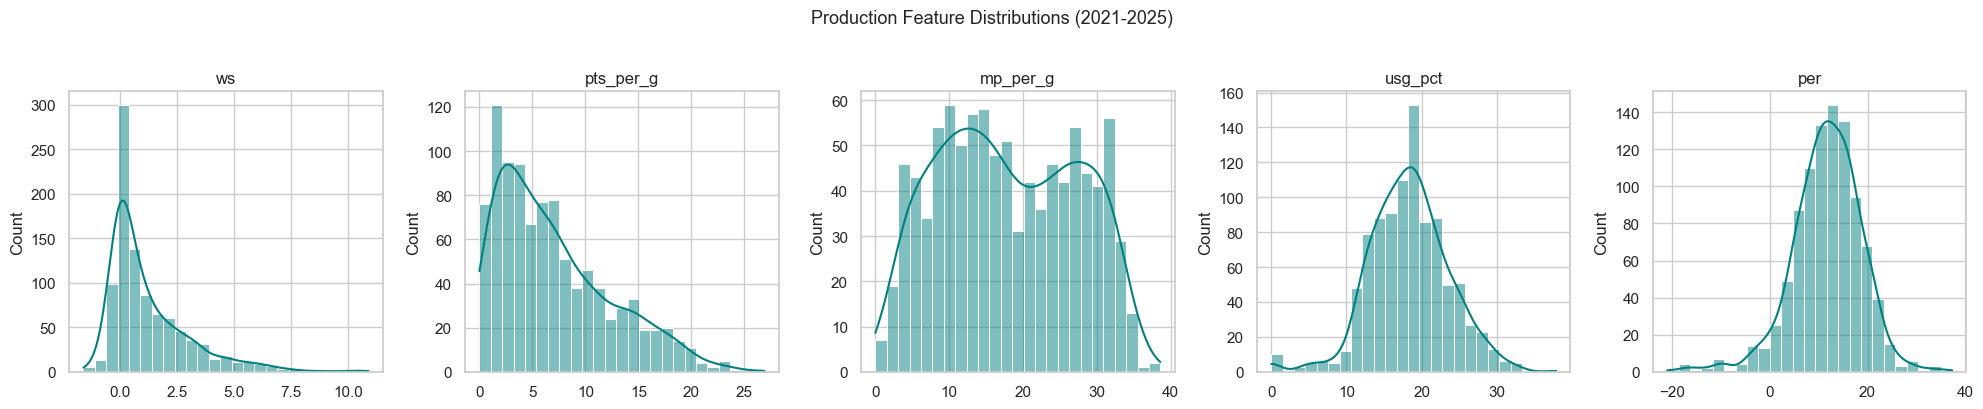

In [13]:
# Key production features distributions
prod_cols = [c for c in ["ws", "pts_per_g", "mp_per_g", "usg_pct", "per"]
             if c in final_df.columns]

fig, axes = plt.subplots(1, len(prod_cols), figsize=(4 * len(prod_cols), 4))
for ax, col in zip(axes, prod_cols):
    sns.histplot(final_df[col].dropna(), kde=True, bins=25, ax=ax, color="teal")
    ax.set_title(col)
    ax.set_xlabel("")

plt.suptitle("Production Feature Distributions (2021-2025)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 4. Missingness Analysis

Identify and quantify missing data across the merged multi-year dataset.
Key concern: `TOT` rows (traded players) will have `NaN` for all team context columns.


In [14]:
# Overall missingness summary
missing_counts = final_df.isna().sum()
missing_pct    = (missing_counts / len(final_df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %":     missing_pct,
}).sort_values("Missing Count", ascending=False)

print("Columns with missing values:")
display(missing_summary[missing_summary["Missing Count"] > 0].head(30))


Columns with missing values:


,Missing Count,Missing %
dummy_team,963,100.00
dummy,963,100.00
arena_name,481,49.95
gb,247,25.65
sos,172,17.86
pace,172,17.86
net_rtg,172,17.86
def_rtg_team,172,17.86
off_rtg_team,172,17.86
srs,172,17.86


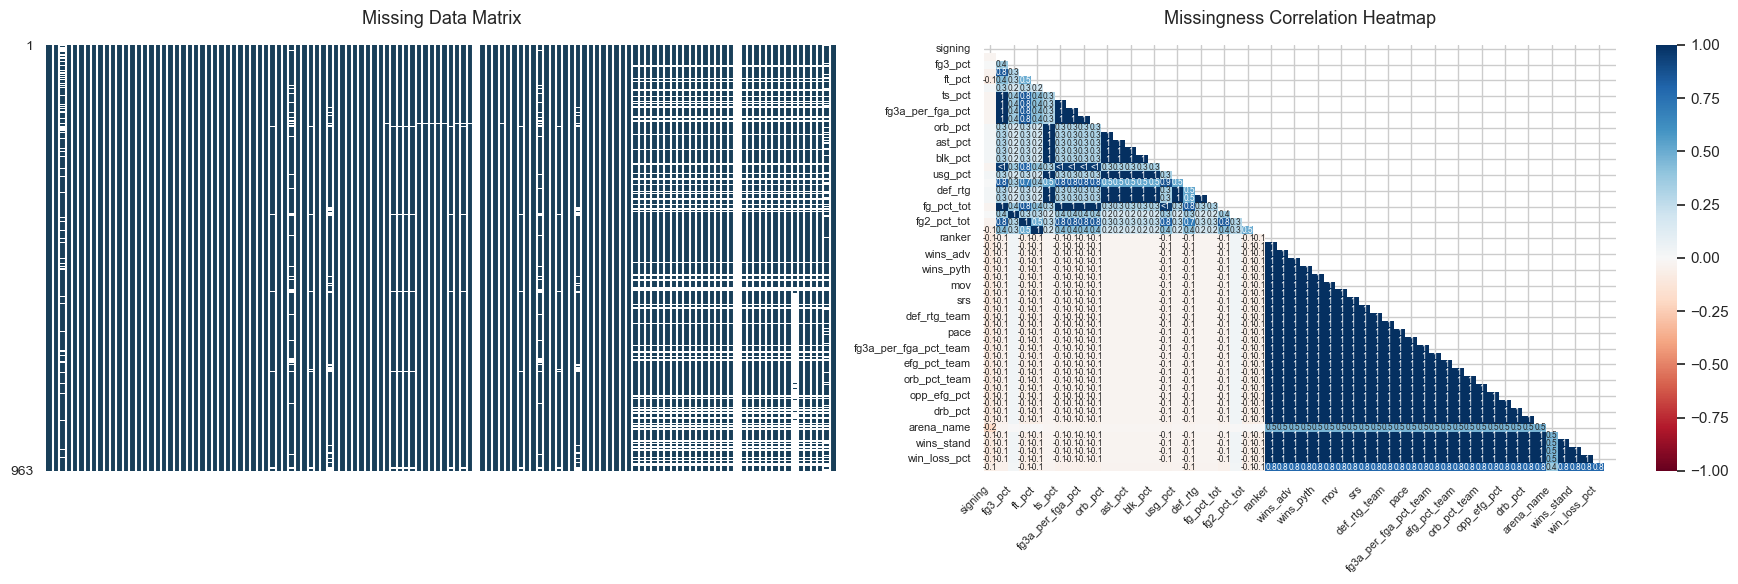

In [15]:
# Missingness matrix
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

msno.matrix(final_df, ax=axes[0], sparkline=False,
            color=(0.1, 0.25, 0.35), fontsize=8)
axes[0].set_title("Missing Data Matrix", fontsize=13, pad=15)

if final_df.isna().sum().sum() > 0:
    msno.heatmap(final_df, ax=axes[1], fontsize=8)
    axes[1].set_title("Missingness Correlation Heatmap", fontsize=13, pad=15)

plt.tight_layout()
plt.show()


In [16]:
# Missingness by season
miss_by_season = (
    final_df.groupby("season")
    .apply(lambda g: g.isna().mean() * 100)
    .T
)
# Show only columns that have any missingness
miss_by_season = miss_by_season[miss_by_season.max(axis=1) > 0]
print("Missing % by season (top columns):")
display(miss_by_season.sort_values(2025, ascending=False).head(20).round(1))


Missing % by season (top columns):


season,2021,2022,2023,2024,2025
dummy_team,100.0,100.0,100.0,100.0,100.0
dummy,100.0,100.0,100.0,100.0,100.0
arena_name,18.2,18.5,12.6,100.0,94.2
gb,24.6,31.5,18.3,20.9,30.8
mov,18.2,18.5,12.6,14.1,24.1
sos,18.2,18.5,12.6,14.1,24.1
srs,18.2,18.5,12.6,14.1,24.1
off_rtg_team,18.2,18.5,12.6,14.1,24.1
def_rtg_team,18.2,18.5,12.6,14.1,24.1
net_rtg,18.2,18.5,12.6,14.1,24.1


## 5. Relationships Between Variables

Correlation heatmap and scatterplots of key production features vs. salary.


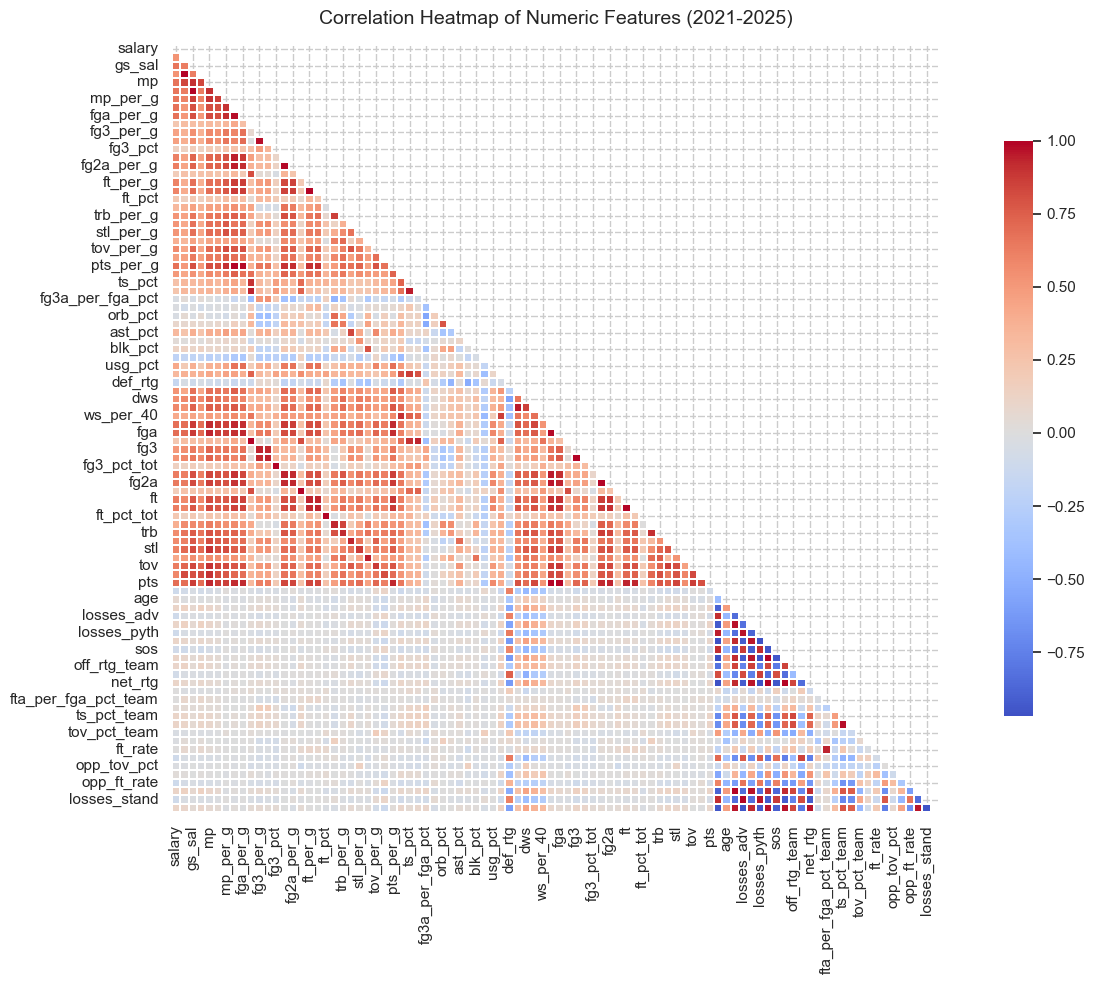

In [17]:
# Correlation heatmap
numeric_df  = final_df.select_dtypes(include=np.number).drop(
    columns=["season", "iso_outlier_signal"], errors="ignore")

# Keep only columns with reasonable coverage
numeric_df = numeric_df.loc[:, numeric_df.notna().mean() > 0.5]

corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0,
            annot=False, square=True, linewidths=0.3,
            cbar_kws={"shrink": 0.75})
plt.title("Correlation Heatmap of Numeric Features (2021-2025)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


In [18]:
# Top correlations with salary 
salary_corr = (corr_matrix["salary"]
               .drop("salary", errors="ignore")
               .dropna()
               .sort_values(key=lambda x: x.abs(), ascending=False))

print("Top 15 features correlated with salary:")
display(salary_corr.head(15).round(4).to_frame("correlation"))


Top 15 features correlated with salary:


,correlation
pts,0.6859
fga,0.6852
fg,0.6819
pts_per_g,0.6769
fga_per_g,0.6734
fg_per_g,0.6704
mp,0.6665
gs,0.6576
gs_sal,0.6576
mp_per_g,0.6553


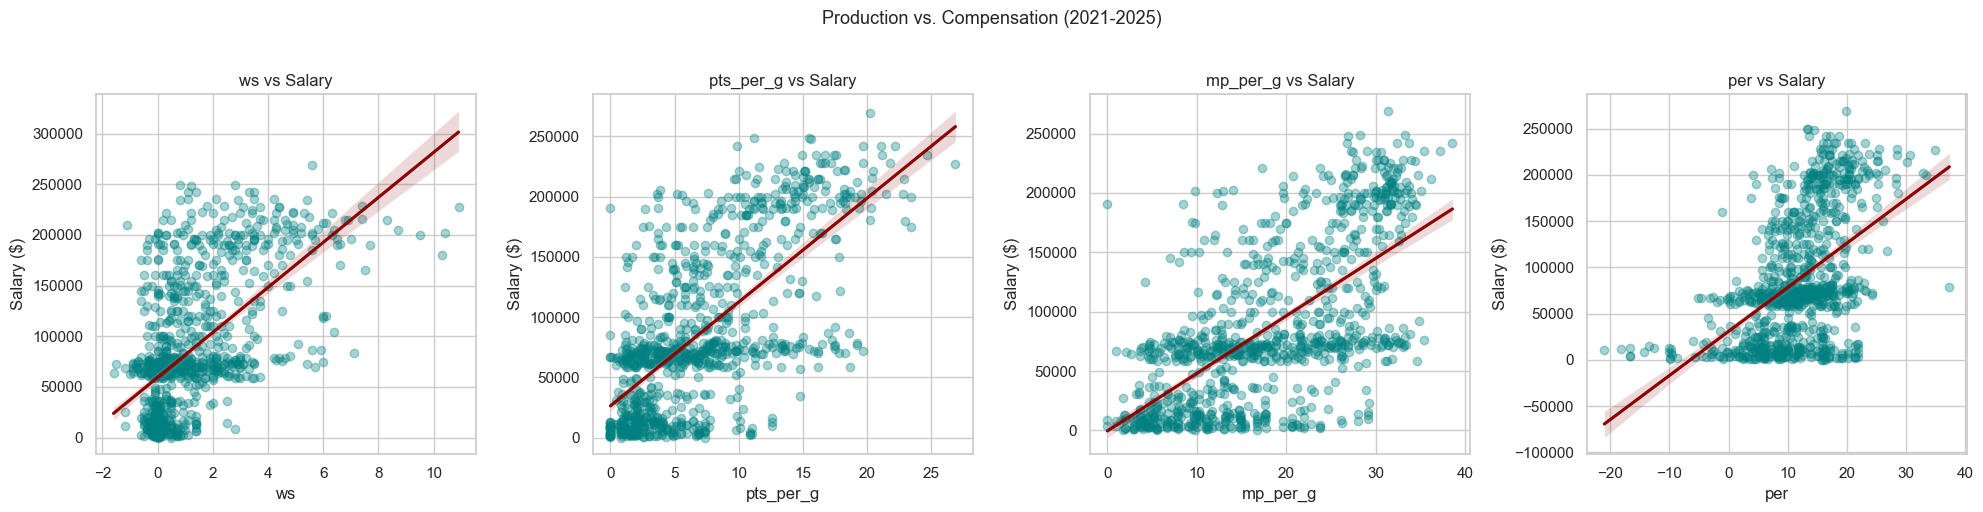

In [19]:
# Key scatterplots: production vs salary
scatter_cols = [c for c in ["ws", "pts_per_g", "mp_per_g", "per"]
                if c in final_df.columns]

fig, axes = plt.subplots(1, len(scatter_cols), figsize=(5 * len(scatter_cols), 5))
for ax, col in zip(axes, scatter_cols):
    sns.regplot(data=final_df, x=col, y="salary", ax=ax,
                scatter_kws={"alpha": 0.35, "color": "teal"},
                line_kws={"color": "darkred"})
    ax.set_title(f"{col} vs Salary")
    ax.set_xlabel(col)
    ax.set_ylabel("Salary ($)")

plt.suptitle("Production vs. Compensation (2021-2025)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


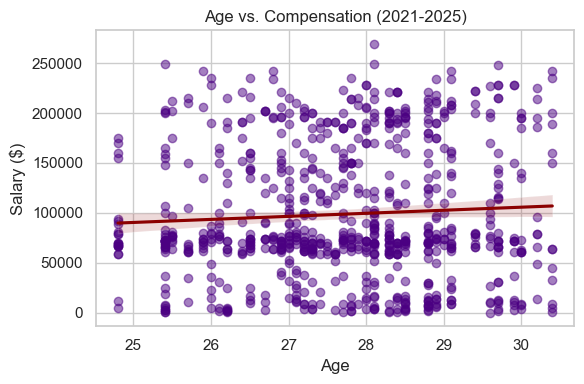

In [20]:
# Age vs salary 
fig, ax = plt.subplots(figsize=(6, 4))

sns.regplot(data=final_df, x="age", y="salary", ax=ax,
            scatter_kws={"alpha": 0.5, "color": "indigo"},
            line_kws={"color": "darkred"})
ax.set_title("Age vs. Compensation (2021-2025)")
ax.set_xlabel("Age")
ax.set_ylabel("Salary ($)")

plt.tight_layout()
plt.show()


In [21]:
# Age group summary table
if "age" in final_df.columns:
    age_group_summary = final_df.groupby("age").agg(
        avg_salary   = ("salary", "mean"),
        player_count = ("salary", "count"),
        avg_ws       = ("ws",     "mean"),
    ).round(2)
    print("Career Trajectory: Average Salary & Production by Age")
    display(age_group_summary)


Career Trajectory: Average Salary & Production by Age


,avg_salary,player_count,avg_ws
age,,,
24.8,84209.59,22,1.24
25.4,80434.50,40,0.77
25.5,106811.08,12,1.32
25.7,92404.00,12,0.62
25.9,104354.00,11,1.22
26.0,89965.08,13,2.08
26.1,84075.15,13,0.85
26.2,74607.83,18,0.77
26.4,127146.20,10,2.48


## 6. Year-over-Year Trends

How have salaries and production metrics changed across the 2021–2025 seasons?
This section is new relative to the 2025-only EDA.


Salary statistics by season:


,median,mean,max,min
season,,,,
2021,66555,83355,221450,464
2022,69224,80706,228094,898
2023,74305,91206,242154,1219
2024,76535,96791,241984,0
2025,72455,82838,269244,0


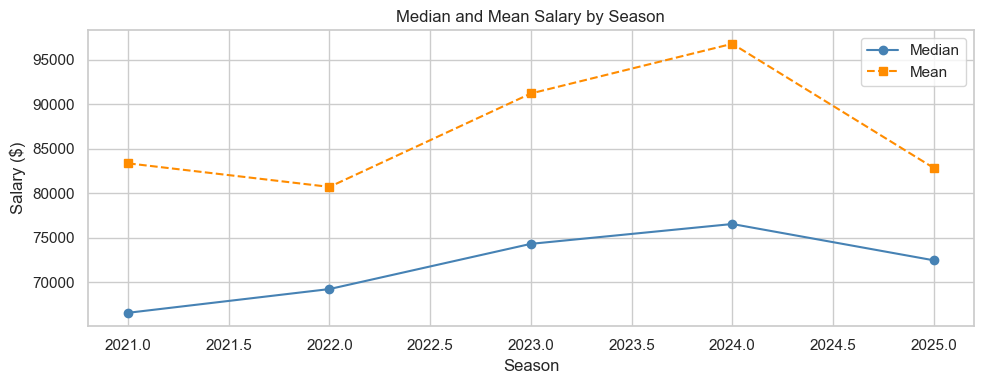

In [22]:
# Median salary per season
salary_trends = (
    final_df.groupby("season")["salary"]
    .agg(["median", "mean", "max", "min"])
    .round(0)
    .astype(int)
)
print("Salary statistics by season:")
display(salary_trends)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(salary_trends.index, salary_trends["median"], marker="o",
        label="Median", color="steelblue")
ax.plot(salary_trends.index, salary_trends["mean"], marker="s",
        linestyle="--", label="Mean", color="darkorange")
ax.set_title("Median and Mean Salary by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Salary ($)")
ax.legend()
plt.tight_layout()
plt.show()


Median production metrics by season:


,ws,pts_per_g,mp_per_g,usg_pct
season,,,,
2021,0.50,5.8,17.8,18.75
2022,0.50,6.0,16.4,17.75
2023,0.50,5.2,16.4,18.15
2024,0.70,5.4,17.5,18.20
2025,0.65,5.8,17.6,18.40


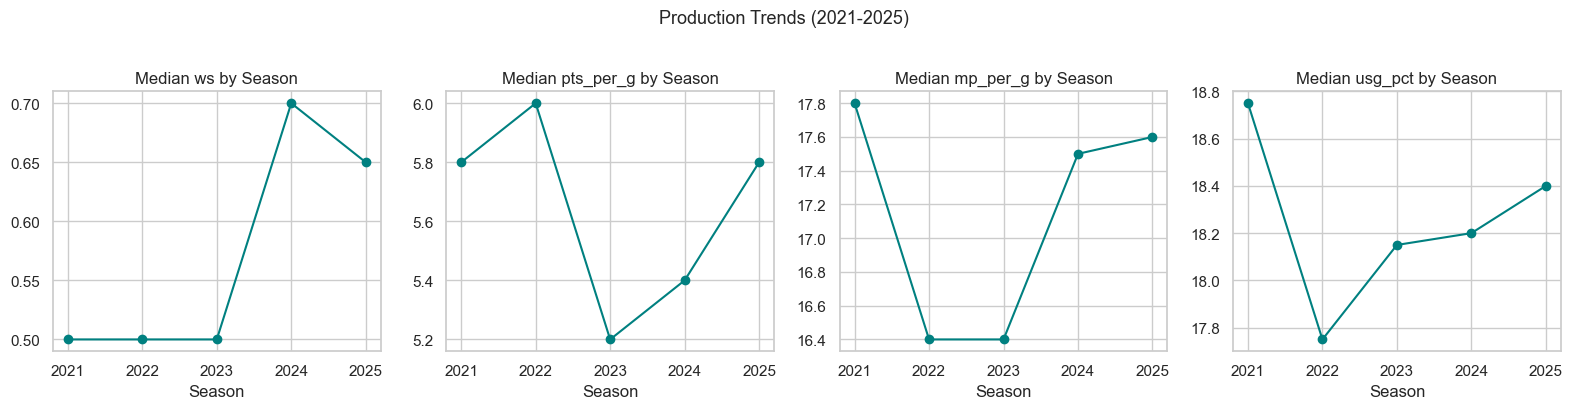

In [23]:
# Median production metrics per season
trend_cols = [c for c in ["ws", "pts_per_g", "mp_per_g", "usg_pct"]
              if c in final_df.columns]

trend_df = final_df.groupby("season")[trend_cols].median().round(2)
print("Median production metrics by season:")
display(trend_df)

fig, axes = plt.subplots(1, len(trend_cols), figsize=(4 * len(trend_cols), 4))
for ax, col in zip(axes, trend_cols):
    ax.plot(trend_df.index, trend_df[col], marker="o", color="teal")
    ax.set_title(f"Median {col} by Season")
    ax.set_xlabel("Season")

plt.suptitle("Production Trends (2021-2025)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


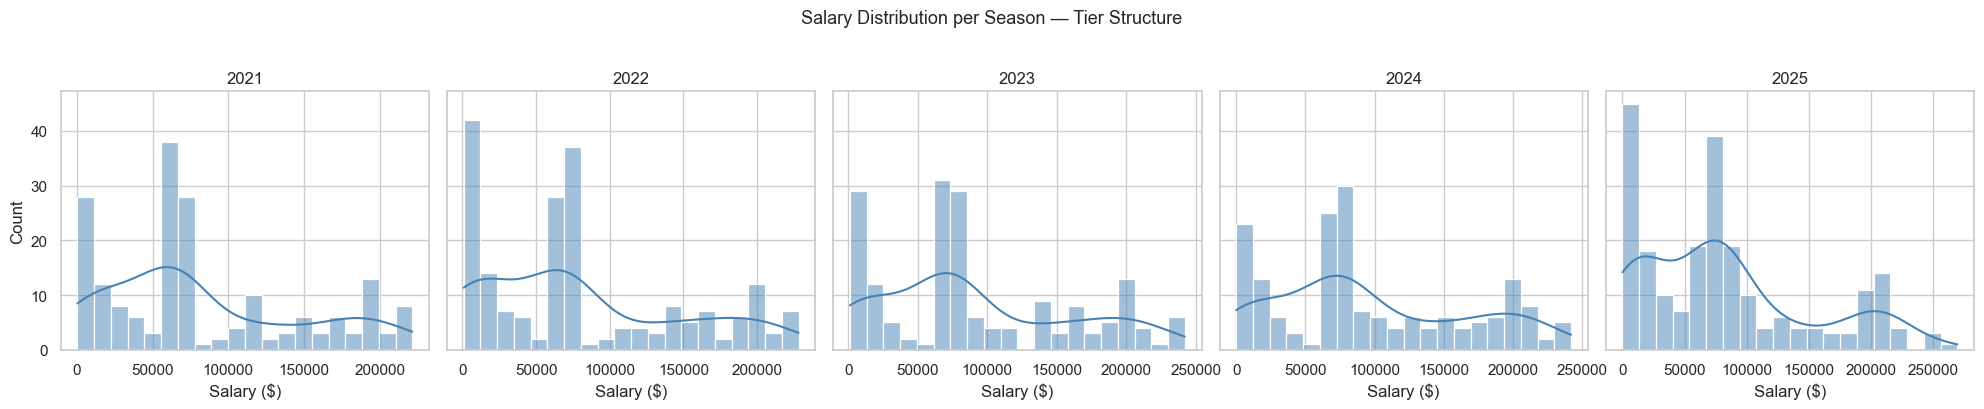

In [24]:
# Salary tier distribution per season
# Shows whether the bimodal/trimodal structure persists across years
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for ax, year in zip(axes, years):
    yr_data = final_df[final_df["season"] == year]["salary"].dropna()
    sns.histplot(yr_data, kde=True, bins=20, ax=ax, color="steelblue")
    ax.set_title(str(year))
    ax.set_xlabel("Salary ($)")

plt.suptitle("Salary Distribution per Season — Tier Structure", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 7. Outlier Detection

Three approaches: visual boxplots, Z-score thresholding, and Isolation Forest.


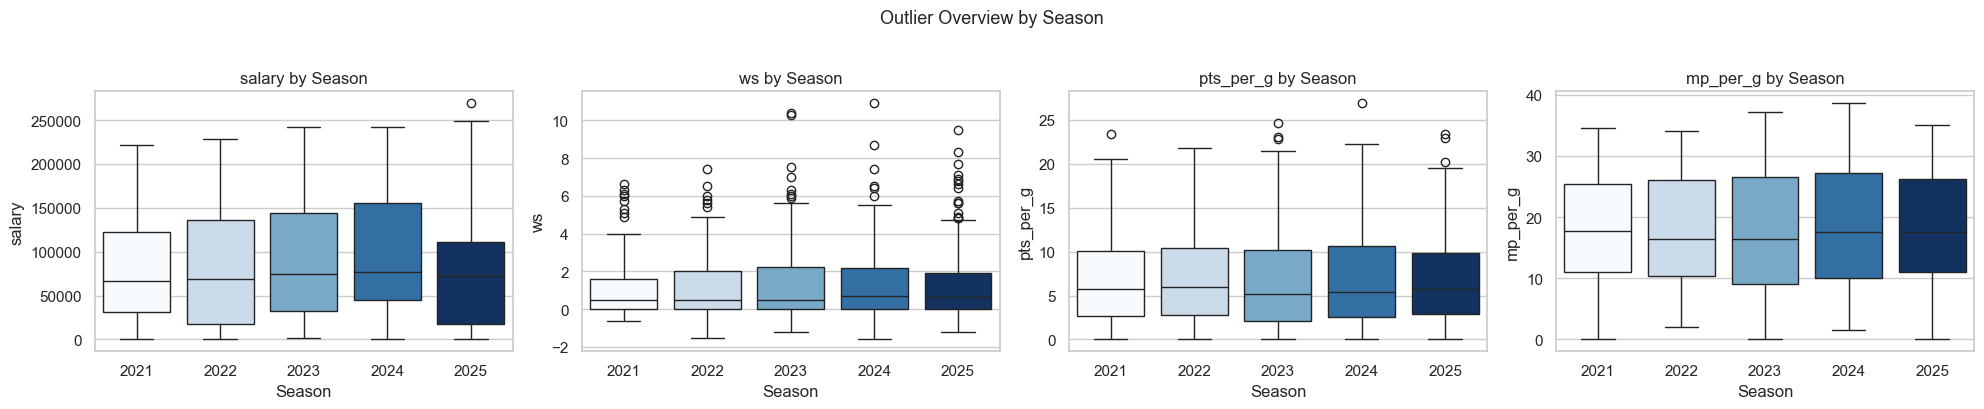

In [26]:
# Boxplots for key features
outlier_cols = [c for c in ["salary", "ws", "pts_per_g", "mp_per_g"]
                if c in final_df.columns]

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(5 * len(outlier_cols), 4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(data=final_df, x="season", y=col, ax=ax, hue="season", palette="Blues", legend=False)
    ax.set_title(f"{col} by Season")
    ax.set_xlabel("Season")

plt.suptitle("Outlier Overview by Season", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


In [27]:
# Z-score outliers 
z_cols = [c for c in ["salary", "ws", "pts_per_g"] if c in final_df.columns]
z_data = final_df[z_cols].fillna(0)
z_scores = np.abs(stats.zscore(z_data))

z_outlier_mask = (z_scores > 3).any(axis=1)
z_outliers_df  = final_df[z_outlier_mask][["player", "season", "team"] + z_cols]

print(f"Z-score outliers (|z| > 3): {z_outlier_mask.sum()} rows")
display(z_outliers_df.sort_values("salary", ascending=False).head(20))


Z-score outliers (|z| > 3): 18 rows


,player,season,team,salary,ws,pts_per_g
387,Jewell Loyd,2023,SEA,234936,3.5,24.7
187,Breanna Stewart,2022,SEA,228094,7.4,21.8
562,A'ja Wilson,2024,LVA,227303,10.9,26.9
566,Napheesa Collier,2024,MIN,215469,7.4,20.4
757,Alyssa Thomas,2025,PHO,215000,6.9,15.4
772,Brionna Jones,2025,ATL,214466,6.8,12.8
740,Napheesa Collier,2025,MIN,214284,8.3,22.9
565,Breanna Stewart,2024,NYL,205000,8.7,20.4
389,A'ja Wilson,2023,LVA,202154,10.4,22.8
739,A'ja Wilson,2025,LVA,200000,9.5,23.4


Isolation Forest flagged 49 outliers (5.1%)


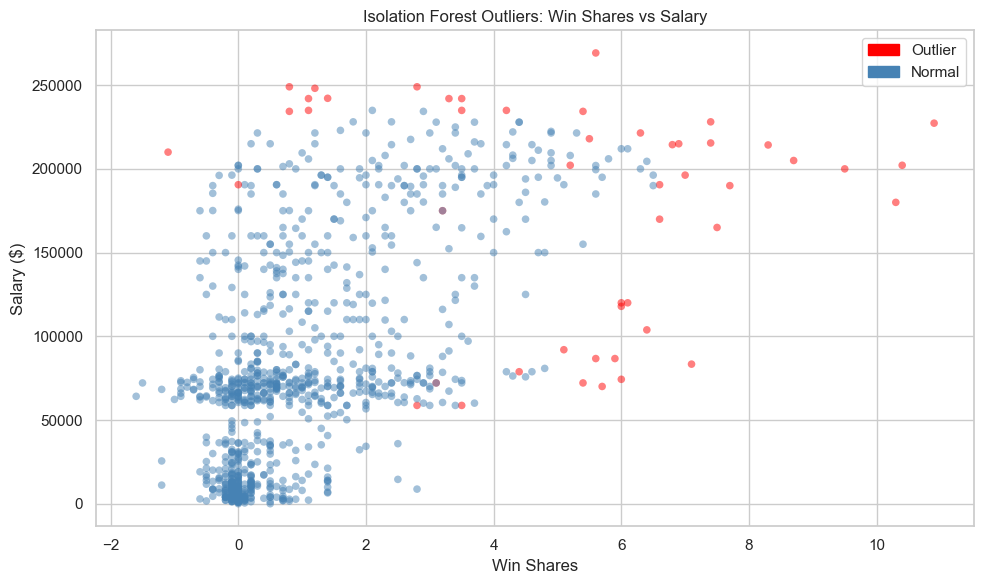

In [28]:
# Isolation Forest outliers
iso_cols = [c for c in ["salary", "ws", "pts_per_g"] if c in final_df.columns]
X_iso = final_df[iso_cols].fillna(0)

iso = IsolationForest(contamination=0.05, random_state=42)
final_df["iso_outlier_signal"] = iso.fit_predict(X_iso)

iso_outliers = final_df[final_df["iso_outlier_signal"] == -1]
print(f"Isolation Forest flagged {len(iso_outliers)} outliers ({len(iso_outliers)/len(final_df)*100:.1f}%)")

# Visualize: salary vs ws, colored by outlier flag
fig, ax = plt.subplots(figsize=(10, 6))
colors = final_df["iso_outlier_signal"].map({1: "steelblue", -1: "red"})
ax.scatter(final_df["ws"], final_df["salary"],
           c=colors, alpha=0.5, edgecolors="none", s=30)
ax.set_xlabel("Win Shares")
ax.set_ylabel("Salary ($)")
ax.set_title("Isolation Forest Outliers: Win Shares vs Salary")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="red", label="Outlier"),
                   Patch(color="steelblue", label="Normal")])
plt.tight_layout()
plt.show()
